In [1]:
from torchvision import transforms, utils
from torchvision.utils import save_image
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F
from random import randint
import torch.nn as nn
from utils import Config, create_ckpt_dir, save_ckpt, load_ckpt, to_items
from PIL import Image
from dataset import InitDataset
from glob import glob
import oyaml as yaml
import numpy as np
import datetime
import random
import torch
from pconv import PConvLayer, PartialConvolution
from loss import InpaintingLoss, VGG16FeatureExtractor
import matplotlib.pyplot as plt
import os

In [2]:
from trainer import Trainer
from pconv_u_net import PConvUNet
from dataset import InitDataset, MaskGenerator

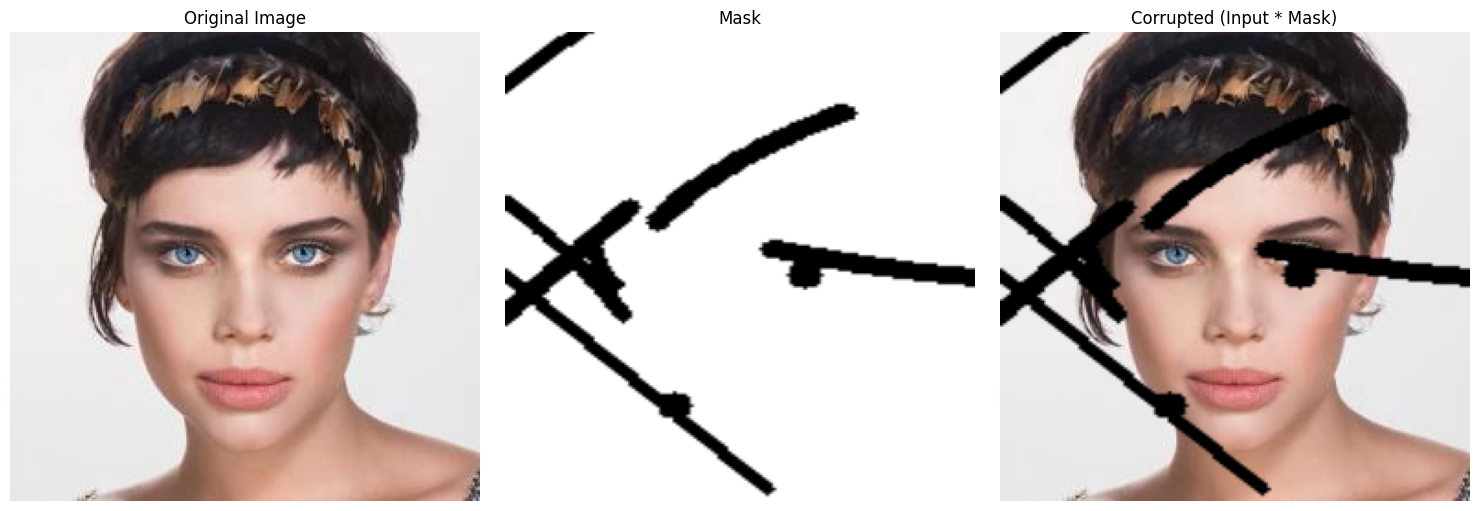

In [3]:
img_tf = transforms.Compose([
            transforms.ToTensor()
            ])

mask_tf = transforms.Compose([
            transforms.RandomResizedCrop(256),
            transforms.ToTensor()
            ])

data = InitDataset('./data_new', img_tf, mask_tf)
# print(data.__len__())
corrupted_img, mask, original_img = data[0]

corrupted_img_np = corrupted_img.permute(1, 2, 0).numpy()
original_img_np = original_img.permute(1, 2, 0).numpy()
mask_np = mask.permute(1, 2, 0).numpy()
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(original_img_np)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(mask_np)
axs[1].set_title("Mask")
axs[1].axis("off")

axs[2].imshow(corrupted_img_np)
axs[2].set_title("Corrupted (Input * Mask)")
axs[2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
config = Config("./config.yml")
config.ckpt = create_ckpt_dir()
print("Check Point is '{}'".format(config.ckpt))

Check Point is './ckpt'


In [5]:
# Data Transformation
img_tf = transforms.Compose([
            transforms.ToTensor()
            ])

mask_tf = transforms.Compose([
            transforms.RandomResizedCrop(256),
            transforms.ToTensor()
            ])


print("Loading the Validation Dataset...")
dataset_val = InitDataset(config.data_root,
                      img_tf,
                      mask_tf,
                      data="test")

print("Loading the Training Dataset...")
dataset_train = InitDataset(config.data_root,
                        img_tf,
                        mask_tf,
                        data="train")

Loading the Validation Dataset...
Loading the Training Dataset...


In [6]:
device = torch.device("cuda:{}".format(config.cuda_id)
                      if torch.cuda.is_available() else "cpu")

print("Loading the Model...")
model = PConvUNet(finetune=config.finetune,
                  layer_size=config.layer_size)

if config.finetune:
    model.load_state_dict(torch.load(config.finetune)['model'])
model.to(device)

# Loss fucntion
criterion = InpaintingLoss(VGG16FeatureExtractor(),
                            tv_loss=config.tv_loss).to(device)
# Optimizer
lr = config.finetune_lr if config.finetune else config.initial_lr
if config.optim == "Adam":
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                        model.parameters()),
                                    lr=lr,
                                    weight_decay=config.weight_decay)
elif config.optim == "SGD":
    optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad,
                                        model.parameters()),
                                lr=lr,
                                momentum=config.momentum,
                                weight_decay=config.weight_decay)


Loading the Model...


/home/mrunal-vairagade/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mrunal-vairagade/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
start_iter = 0
trainer = Trainer(start_iter, config, device, model, dataset_train,
                    dataset_val, criterion, optimizer)
last_saved_model, losses = trainer.iterate()

Start the training
[STEP:      0] | Valid Loss: 0.608123 | Hole Loss: 0.157793| TV Loss: 0.573949 | Perc Loss: 39.285801| Style Loss: 6.489132 | Total Loss: 782.272400
Start the evaluation
Saved evaluation result to ./ckpt/val_vis/0.png
[STEP:      1] | Valid Loss: 0.668916 | Hole Loss: 0.129307| TV Loss: 0.493767 | Perc Loss: 35.151478| Style Loss: 7.113705 | Total Loss: 856.896240
Start the evaluation
Saved evaluation result to ./ckpt/val_vis/1.png
Saving the model...
[STEP:      2] | Valid Loss: 0.675835 | Hole Loss: 0.113900| TV Loss: 0.329637 | Perc Loss: 28.418884| Style Loss: 2.559618 | Total Loss: 309.967285
Start the evaluation
Saved evaluation result to ./ckpt/val_vis/2.png
[STEP:      3] | Valid Loss: 0.582192 | Hole Loss: 0.118838| TV Loss: 0.282956 | Perc Loss: 26.562616| Style Loss: 2.275164 | Total Loss: 275.671295
Start the evaluation
Saved evaluation result to ./ckpt/val_vis/3.png
Saving the model...
[STEP:      4] | Valid Loss: 0.488689 | Hole Loss: 0.082221| TV Loss:

In [9]:
losses

[{'valid': 0.6081229448318481,
  'hole': 0.15779253840446472,
  'perc': 39.28580093383789,
  'style': 6.489132404327393,
  'tv': 0.5739492177963257,
  'total': 782.2723999023438},
 {'valid': 0.6689159870147705,
  'hole': 0.1293066143989563,
  'perc': 35.1514778137207,
  'style': 7.113704681396484,
  'tv': 0.4937666058540344,
  'total': 856.896240234375},
 {'valid': 0.675835371017456,
  'hole': 0.11389953643083572,
  'perc': 28.41888427734375,
  'style': 2.559617757797241,
  'tv': 0.329636812210083,
  'total': 309.96728515625},
 {'valid': 0.5821923613548279,
  'hole': 0.11883813887834549,
  'perc': 26.5626163482666,
  'style': 2.2751636505126953,
  'tv': 0.2829558253288269,
  'total': 275.6712951660156},
 {'valid': 0.48868927359580994,
  'hole': 0.08222079277038574,
  'perc': 19.385805130004883,
  'style': 1.2045931816101074,
  'tv': 0.13649791479110718,
  'total': 146.51614379882812},
 {'valid': 0.6123021841049194,
  'hole': 0.05088276043534279,
  'perc': 17.068906784057617,
  'style':

In [ ]:
start_iter = last_saved_model

ckpt_dir = "./ckpt/models"
ckpt_path = os.path.join(ckpt_dir, f"{start_iter}.pth")
ckpt_dict = torch.load(ckpt_path, map_location="cpu")
# print(ckpt_dict.keys())
try:
    n_iter = load_ckpt(ckpt_path, [("model", model)], [("optimizer", optimizer)])
    print(f"✅ Loaded checkpoint from {ckpt_path}, resuming from iteration {n_iter}")
except FileNotFoundError:
    print("❌ No checkpoint found. Starting training from scratch.")
    n_iter = 0

start_iter = n_iter
trainer = Trainer(start_iter, config, device, model, dataset_train,
                    dataset_val, criterion, optimizer)
trainer.iterate()

In [ ]:
import torchvision.transforms as T

# Load image
img = Image.open('/content/drive/MyDrive/Image Inpainting MIC/data_new/train/06000.jpg').convert('RGB')

# Transform: resize & tensor conversion
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])
input_tensor = transform(img).unsqueeze(0).to(device)  # shape: [1, 3, 256, 256]

# Generate a random irregular mask
def random_mask(size=(256, 256), hole_size=(50, 100)):
    mask = torch.ones(1, 1, *size)
    num_holes = random.randint(1, 5)
    for _ in range(num_holes):
        h, w = random.randint(*hole_size), random.randint(*hole_size)
        y = random.randint(0, size[0] - h)
        x = random.randint(0, size[1] - w)
        mask[:, :, y:y + h, x:x + w] = 0
    return mask

mask_tensor = random_mask().to(device)  # shape: [1, 1, 256, 256]
mask_tensor = mask_tensor.expand_as(input_tensor)  # shape: [1, 3, 256, 256]

# Apply mask
corrupted_tensor = input_tensor * mask_tensor  # zero out masked regions

# Run model inference
model.eval()
with torch.no_grad():
    output_tensor, _ = model(corrupted_tensor, mask_tensor)

# Composite: paste prediction into masked region
output_comp = mask_tensor * input_tensor + (1 - mask_tensor) * output_tensor

# Visualize
def imshow_tensor(tensor, title):
    img = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
imshow_tensor(input_tensor, "Original")

plt.subplot(1, 4, 2)
imshow_tensor(mask_tensor, "Mask")

plt.subplot(1, 4, 3)
imshow_tensor(corrupted_tensor, "Corrupted")

plt.subplot(1, 4, 4)
imshow_tensor(output_comp, "Output Composite")
plt.tight_layout()
plt.show()
